# K-Nearest Neighbors - Classificação de clientes bancários 
=======================================

**Disciplina:** Aprendizado de máquina 

**Aluna:** Bruna Henrique Fujihashi

**Monstro:** Cubo gelatinoso



## Introdução 

## Treinando o modelo 

### Bibliotecas 

In [27]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


### Coletando os dados 

aqui vamos exportar os dados de interesse para a nosso treinamento

In [2]:
banco = pd.read_csv("bank_organizado.csv")

print(banco)

      age            job  marital  education default  balance housing loan  \
0      30     unemployed  married    primary      no     1787      no   no   
1      33       services  married  secondary      no     4789     yes  yes   
2      35     management   single   tertiary      no     1350     yes   no   
3      30     management  married   tertiary      no     1476     yes  yes   
4      59    blue-collar  married  secondary      no        0     yes   no   
...   ...            ...      ...        ...     ...      ...     ...  ...   
4516   33       services  married  secondary      no     -333     yes   no   
4517   57  self-employed  married   tertiary     yes    -3313     yes  yes   
4518   57     technician  married  secondary      no      295      no   no   
4519   28    blue-collar  married  secondary      no     1137      no   no   
4520   44   entrepreneur   single   tertiary      no     1136     yes  yes   

       contact  day month  duration  campaign  pdays  previous 

In [3]:
banco.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [4]:
banco.shape

(4521, 17)

In [5]:
banco.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [6]:
# mostrar quantidade de observações e atributos 

In [7]:
# ver os tipos de variáveis 

### Análise inicial do dataset

In [8]:
ATRIBUTOS = ["age", "job", "marital", "education", "balance", "housing", "loan"]

X= banco[ATRIBUTOS]
Y= banco["y"] 

In [9]:
# mostrar quantas observações foram encontradas 

In [10]:
# ver quais atributos temos 

In [11]:
# Como estão distribuidas as classes ?

In [12]:
# 

### Separação entre treino e teste

In [13]:
# Vamos separar os dados de treino para o modelo 
from sklearn.model_selection import train_test_split

TAMANHO_TESTE = 0.1 # dados que vão para teste
SEMENTE_ALEATORIA = 61455 # vai gerar sempre a mesma célula 

indices = banco.index

indices_treino, indices_teste = train_test_split(
    indices,
     test_size=TAMANHO_TESTE, 
     random_state=SEMENTE_ALEATORIA
)

df_treino = banco.loc[indices_treino]
df_teste = banco.loc[indices_teste]

In [14]:
df_treino

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
1544,35,management,married,tertiary,no,1100,no,yes,cellular,29,jan,127,2,-1,0,unknown,no
3689,29,technician,married,tertiary,no,858,yes,no,cellular,12,jun,234,7,330,1,failure,no
4389,34,management,married,tertiary,no,436,no,yes,cellular,28,jul,118,4,-1,0,unknown,no
2091,54,services,married,secondary,no,-22,no,yes,cellular,9,jul,85,1,-1,0,unknown,no
2989,42,entrepreneur,married,tertiary,no,42045,no,no,cellular,8,aug,205,2,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,42,housemaid,married,primary,no,145,no,no,cellular,20,aug,252,2,-1,0,unknown,no
4499,45,blue-collar,divorced,primary,no,942,no,no,cellular,21,nov,362,1,-1,0,unknown,no
2256,41,management,single,secondary,no,764,no,no,cellular,12,jun,230,2,-1,0,unknown,no
2480,35,admin.,divorced,secondary,no,3636,no,yes,cellular,21,nov,808,2,-1,0,unknown,yes


In [15]:
df_teste

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
1575,34,blue-collar,single,primary,no,464,yes,no,cellular,18,may,173,1,299,2,other,no
1186,71,technician,married,tertiary,no,383,no,no,cellular,27,oct,327,2,183,3,success,no
3118,32,services,married,secondary,no,1464,yes,no,unknown,3,jun,193,1,-1,0,unknown,no
2277,38,technician,married,secondary,no,1931,no,no,cellular,2,jun,167,1,298,10,other,no
3908,36,technician,married,tertiary,no,167,yes,no,cellular,28,jan,57,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3044,53,entrepreneur,married,unknown,no,7,no,no,cellular,20,nov,68,1,-1,0,unknown,no
4120,31,self-employed,single,tertiary,yes,-282,yes,no,cellular,20,nov,131,3,-1,0,unknown,no
1535,37,services,married,secondary,no,4760,yes,no,cellular,8,may,182,2,169,2,failure,no
1842,59,retired,divorced,primary,no,7179,no,no,cellular,5,feb,150,1,-1,0,unknown,no


### Tratamento das variáveis categóricas 

In [16]:
# aqui vamos tratar os dados categóricos: job, education e marital 

# Verificar o OneHotEnconder do professor
from sklearn.preprocessing import OneHotEncoder

ATRIBUTOS_CATEGORICOS = ["job", "marital", "education"]

# handle_unknown="ignore": se uma categoria aparecer no teste sem nunca ter
# aparecido no treino, essa linha vira tudo zero em vez de dar erro
codificador = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# fit só no treino -> só ele decide quais categorias existem
codificador.fit(df_treino[ATRIBUTOS_CATEGORICOS])

colunas_codificadas = codificador.get_feature_names_out(ATRIBUTOS_CATEGORICOS)

treino_codificado = pd.DataFrame(
    codificador.transform(df_treino[ATRIBUTOS_CATEGORICOS]),
    columns = colunas_codificadas, 
    index = df_treino.index,
)

teste_codificado = pd.DataFrame(
    codificador.transform(df_teste[ATRIBUTOS_CATEGORICOS]),
    columns = colunas_codificadas, 
    index = df_teste.index,
)

df_treino = pd.concat([df_treino.drop(columns=ATRIBUTOS_CATEGORICOS), treino_codificado], axis=1)
df_teste = pd.concat([df_teste.drop(columns=ATRIBUTOS_CATEGORICOS), teste_codificado], axis=1)


### Tratamento das variáveis binárias 

In [17]:
MAPA_BINARIO = {"yes": 1, "no": 0}

ATRIBUTOS_BINARIOS = ["housing", "loan"]

for atributo in ATRIBUTOS_BINARIOS:
    df_treino[atributo] = df_treino[atributo].map(MAPA_BINARIO)
    df_teste[atributo] = df_teste[atributo].map(MAPA_BINARIO)

### Junção dos tratamentos 

In [18]:
ATRIBUTOS = ["age", "balance", "housing", "loan"] + list(colunas_codificadas)
TARGET = "y"

X_treino = df_treino[ATRIBUTOS]
Y_treino = df_treino[TARGET]

X_teste = df_teste[ATRIBUTOS]
Y_teste = df_teste[TARGET]

X_treino.head()

,age,balance,housing,loan,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown
1544,35,1100,0,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3689,29,858,1,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4389,34,436,0,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2091,54,-22,0,1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2989,42,42045,0,0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### Normalização

In [19]:
# Normalização dos dados, no geral, principalmente para minimizar os efeitos das variáveis numéricas que diferem muito em valor 
from sklearn.preprocessing import StandardScaler

normalizador = StandardScaler()
normalizador.fit(X_treino)

X_treino_norm = pd.DataFrame(
    normalizador.transform(X_treino), columns=X_treino.columns, index=X_treino.index
)

X_teste_norm = pd.DataFrame(
    normalizador.transform(X_teste), columns=X_teste.columns, index=X_teste.index
)

In [20]:
X_teste_norm.head()

,age,balance,housing,loan,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown
1575,-0.678757,-0.313184,0.874125,-0.426061,-0.345583,1.938529,-0.191565,-0.16037,-0.522723,-0.229772,...,-0.450376,-0.173592,-0.084735,-0.36619,-1.264658,1.659147,2.371794,-1.022877,-0.648376,-0.208835
1186,2.821319,-0.339993,-1.144002,-0.426061,-0.345583,-0.515855,-0.191565,-0.16037,-0.522723,-0.229772,...,2.220367,-0.173592,-0.084735,-0.36619,0.790727,-0.602719,-0.421622,-1.022877,1.542316,-0.208835
3118,-0.867950,0.017786,0.874125,-0.426061,-0.345583,-0.515855,-0.191565,-0.16037,-0.522723,-0.229772,...,-0.450376,-0.173592,-0.084735,-0.36619,0.790727,-0.602719,-0.421622,0.977635,-0.648376,-0.208835
2277,-0.300370,0.172350,-1.144002,-0.426061,-0.345583,-0.515855,-0.191565,-0.16037,-0.522723,-0.229772,...,2.220367,-0.173592,-0.084735,-0.36619,0.790727,-0.602719,-0.421622,0.977635,-0.648376,-0.208835
3908,-0.489563,-0.411483,0.874125,-0.426061,-0.345583,-0.515855,-0.191565,-0.16037,-0.522723,-0.229772,...,2.220367,-0.173592,-0.084735,-0.36619,0.790727,-0.602719,-0.421622,-1.022877,1.542316,-0.208835


### Construção do KNN

Terminar o analisando a acurácia e a matriz de confisão para cada resultados e dsicutir 

#### KNN com os dados brutos 

In [30]:
NUM_VIZINHOS = 3 

modelo_bruto = KNeighborsClassifier(NUM_VIZINHOS)
modelo_bruto.fit(X_treino, Y_treino)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


<Axes: >

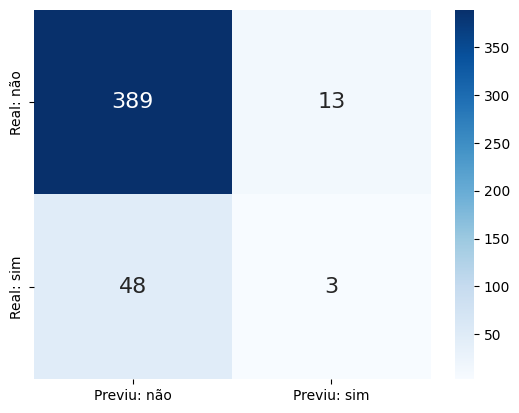

In [48]:
ordem_labels = ["no", "yes"]

y_verdadeiro_bruto = Y_teste
y_previsao_bruto = modelo_bruto.predict(X_teste)

matriz_conf_bruto = confusion_matrix(y_verdadeiro_bruto, y_previsao_bruto, labels=["no", "yes"])
df_conf_bruto = pd.DataFrame(
    matriz_conf_bruto, index=["Real: não", "Real: sim"], columns=["Previu: não", "Previu: sim"]
)

sns.heatmap(df_conf_bruto, annot=True, fmt="d", annot_kws={"size" : 16}, cmap="Blues")

In [50]:
acuracia_bruto = accuracy_score(Y_teste, Y_previsao_bruto)
f1_bruto = f1_score(Y_teste, Y_previsao_bruto, pos_label="yes")

print(f"Acurácia: {accuracy_score(y_verdadeiro_bruto, y_previsao_bruto)*100:.2f}%")
print(f"F1-score: {f1_score(y_verdadeiro_bruto, y_previsao_bruto, pos_label='yes'):.4f}")

Acurácia: 86.53%
F1-score: 0.0896


#### KNN com os dados normalizados 

In [57]:
NUM_VIZINHOS = 3 

modelo_norm = KNeighborsClassifier(NUM_VIZINHOS)
modelo_norm.fit(X_treino_norm, Y_treino)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


<Axes: >

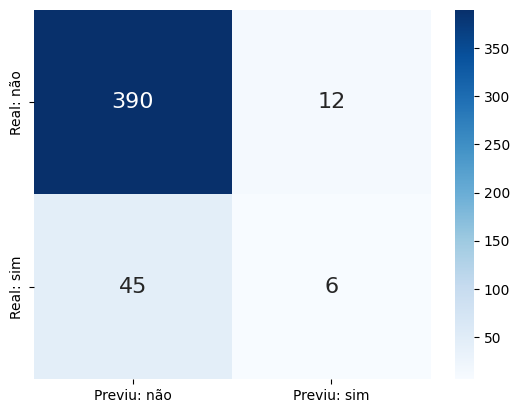

In [60]:
ordem_labels = ["no", "yes"]

y_verdadeiro_norm = Y_teste
y_previsao_norm = modelo_norm.predict(X_teste_norm)

matriz_conf_norm = confusion_matrix(y_verdadeiro_norm, y_previsao_norm, labels=["no", "yes"])
df_conf_norm = pd.DataFrame(
    matriz_conf_norm, index=["Real: não", "Real: sim"], columns=["Previu: não", "Previu: sim"]
)

sns.heatmap(df_conf_norm, annot=True, fmt="d", annot_kws={"size" : 16}, cmap="Blues")

In [61]:
acuracia_norm = accuracy_score(Y_teste, Y_previsao_norm)
f1_norm = f1_score(Y_teste, Y_previsao_norm, pos_label="yes")

print(f"Acurácia: {accuracy_score(y_verdadeiro_norm, y_previsao_norm)*100:.2f}%")
print(f"F1-score: {f1_score(y_verdadeiro_norm, y_previsao_norm, pos_label='yes'):.4f}")

Acurácia: 87.42%
F1-score: 0.1739


### Definição dos hiperparâmetros 

In [45]:
from itertools import product

# Produto cartesiano para testar todas as combinações possíveis
VALORES_K = [1, 3, 5, 7, 9, 11, 15, 21]  # ímpares, para evitar empate de votos (explico abaixo)
FUNCOES_DISTANCIA = ["euclidean", "manhattan", "chebyshev"]

resultados = []

for k, funcao_distancia in product(VALORES_K, FUNCOES_DISTANCIA):
    # Instanciamos o modelo com esses valores
    modelo = KNeighborsClassifier(
        n_neighbors=k,
        metric=funcao_distancia,
    )

    modelo.fit(X_treino_norm, Y_treino)

    Y_verdadeiro = Y_teste
    Y_previsao = modelo.predict(X_teste_norm)
    F1 = f1_score(Y_verdadeiro, Y_previsao, pos_label="yes")
    ACURACIA = accuracy_score(Y_verdadeiro, Y_previsao)

    print(
        f"O F1-score do modelo k-NN usando k={k} "
        f"e distância={funcao_distancia} foi de {F1:.4f} (acurácia: {ACURACIA*100:.1f}%)."
    )

    # O desempenho do modelo depende dos hiperparâmetros. Quanto maior o F1-score, melhor foi o desempenho
    # (diferente do RMSE do exemplo do professor, aqui é "quanto maior, melhor", não "quanto menor").
    resultados.append({"k": k, "funcao_distancia": funcao_distancia, "f1_score": F1, "acuracia": ACURACIA})

df_resultados = pd.DataFrame(resultados)

O F1-score do modelo k-NN usando k=1 e distância=euclidean foi de 0.1386 (acurácia: 80.8%).
O F1-score do modelo k-NN usando k=1 e distância=manhattan foi de 0.1616 (acurácia: 81.7%).
O F1-score do modelo k-NN usando k=1 e distância=chebyshev foi de 0.1553 (acurácia: 80.8%).
O F1-score do modelo k-NN usando k=3 e distância=euclidean foi de 0.1739 (acurácia: 87.4%).
O F1-score do modelo k-NN usando k=3 e distância=manhattan foi de 0.1449 (acurácia: 87.0%).
O F1-score do modelo k-NN usando k=3 e distância=chebyshev foi de 0.1194 (acurácia: 87.0%).
O F1-score do modelo k-NN usando k=5 e distância=euclidean foi de 0.0656 (acurácia: 87.4%).
O F1-score do modelo k-NN usando k=5 e distância=manhattan foi de 0.0645 (acurácia: 87.2%).
O F1-score do modelo k-NN usando k=5 e distância=chebyshev foi de 0.0984 (acurácia: 87.9%).
O F1-score do modelo k-NN usando k=7 e distância=euclidean foi de 0.1017 (acurácia: 88.3%).
O F1-score do modelo k-NN usando k=7 e distância=manhattan foi de 0.1000 (acurác

Melhor combinação: k=3, distância=euclidean
F1-score: 0.1739


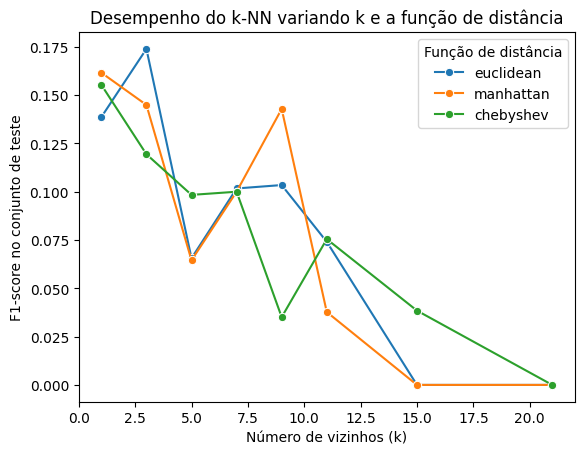

In [62]:
melhor_combinacao = df_resultados.sort_values("f1_score", ascending=False).iloc[0]
MELHOR_K = int(melhor_combinacao["k"])
MELHOR_DISTANCIA = melhor_combinacao["funcao_distancia"]

print(f"Melhor combinação: k={MELHOR_K}, distância={MELHOR_DISTANCIA}")
print(f"F1-score: {melhor_combinacao['f1_score']:.4f}")

eixo = sns.lineplot(data=df_resultados, x="k", y="f1_score", hue="funcao_distancia", marker="o")
eixo.set(xlabel="Número de vizinhos (k)", ylabel="F1-score no conjunto de teste",
         title="Desempenho do k-NN variando k e a função de distância")
eixo.legend(title="Função de distância");

### Modelo Baseline 

não repeti essa comparação para o baseline porque o DummyClassifier com estratégia prior ignora os atributos de entrada, então normalizar os dados não teria nenhum efeito na previsão

In [70]:
from sklearn.dummy import DummyClassifier

ordem_labels = ["no", "yes"]

modelo_baseline = DummyClassifier()
modelo_baseline.fit(X_treino, Y_treino)

,strategy,'prior'
,random_state,None
,constant,None


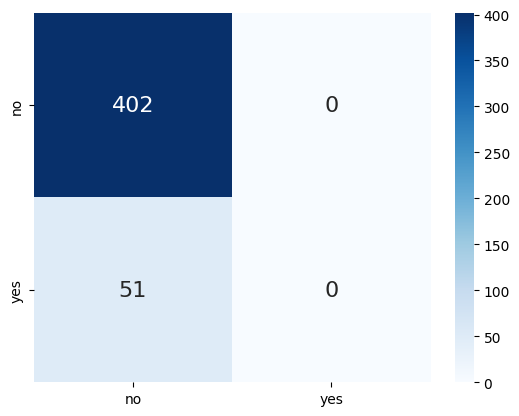

In [71]:
y_verdadeiro = Y_teste
y_previsao = modelo_baseline.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, fmt="d", annot_kws={"size": 16}, cmap="Blues");

In [72]:
acuracia_baseline = accuracy_score(y_verdadeiro, y_previsao)
f1_baseline = f1_score(y_verdadeiro, y_previsao, pos_label="yes")

print(f"Acurácia = {acuracia_baseline*100:.2f}%")
print(f"F1-score = {f1_baseline:.4f}")

Acurácia = 88.74%
F1-score = 0.0000


### Comparação da eficácia entre Baseline e KNN 

##  Conclusões e principais aprendizados 

## Referências bibliográficas 

## Declaração do uso de IA 